In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})


# Total Chemical Potential

The total chemical potential in a fluid is given by:

$\mu = \mu_\text{id} + \mu_\text{ex}$

- $\mu_\text{id}$ is the ideal gas contribution,
- $\mu_\text{ex}$ is the excess chemical potential due to
    intermolecular interactions.

# Ideal Gas Contribution

The ideal gas chemical potential is:

$\mu_\text{id} = k_B T \ln(\rho \Lambda^3)$

where $\rho = N/V$ is the number density and $\Lambda$ is the thermal de Broglie wavelength:

$\Lambda = \sqrt{\frac{h^2}{2 \pi m k_B T}}$

- $h = 6.626 \times 10^{-34}\ \mathrm{J\ s}$ (Planck's constant),
- $m = \frac{44.01\ \mathrm{g/mol}}{6.022 \times 10^{23}}\approx 7.308\times 10^{-26}\ \mathrm{kg}$ (mass of one CO2 molecule),
- $k_B = 1.3806 \times 10^{-23}\ \mathrm{J/K}$ (Boltzmann constant),
- $T = 300$ K.

$\to \Lambda = 0.152 \mathrm{\AA{}}$

In [2]:
mu_vs_N_gcmc_lammps = np.loadtxt("GCMC-LAMMPS/number_vs_mu.dat")
mu_vs_N_gcmc_maniac = np.loadtxt("GCMC-MANIAC/number_vs_mu.dat")

In [4]:
MANIAC = r'MANIAC (v0.3.5-beta)'
LAMMPS = r'LAMMPS (22 Jul 2025)'

In [10]:
V = 40**3

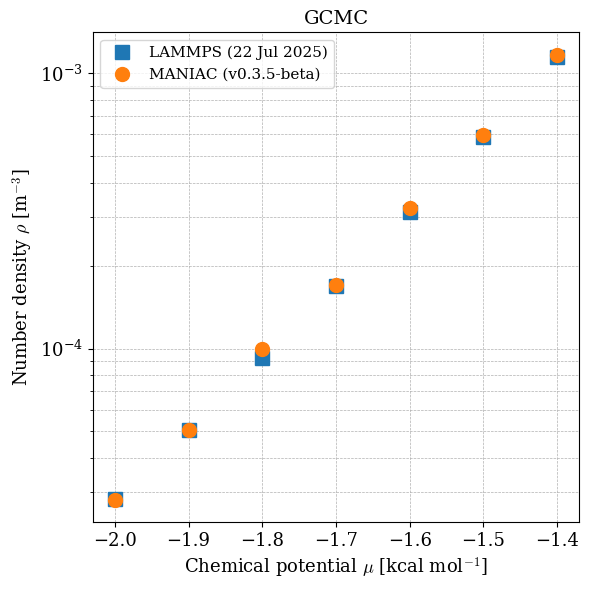

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharey=True)

# LAMMPS
N = mu_vs_N_gcmc_lammps[:,1]
mu = mu_vs_N_gcmc_lammps[:,0]
rho = N / V
ax.semilogy(mu, rho, 's', label=LAMMPS, markersize=10)

# MANIAC
N = mu_vs_N_gcmc_maniac[:,1]
mu = mu_vs_N_gcmc_maniac[:,0]
rho = N / V
ax.semilogy(mu, rho, 'o', label=MANIAC, markersize=10)

ax.set_xlabel(r'Chemical potential $\mu$ [kcal mol$^{-1}$]', fontsize=13)
ax.set_ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=13)
ax.set_title(r'GCMC', fontsize=14)
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend(fontsize=11)

# FINAL
plt.tight_layout()
plt.savefig("Maniac_vs_LAMMPS.png", dpi=300)
plt.show()
